# Backtest v5 — ORB + ITSM Confluence Strategy

**ITSM (Intraday Time-Series Momentum):** first-30-min return predicts rest-of-day direction.  
Only take ORB breakouts that **agree** with early-session momentum (long + up-morning, short + down-morning).

**v5 parameters (CSCV best variant, 84.8% OOS success rate):**
- SL=70 pts | TP=140 pts (2:1 RR)
- OR=8 bars (40-min opening range: 9:30-10:10)
- EMA=10 | RSI 52/48
- ITSM: sign of close(10:00) / open(9:30) - 1

**No look-ahead:** ITSM confirmed at 10:00 (bar 5 close); OR ends at 10:10; earliest entry 10:15.

**4 variants compared:**
1. Baseline v3: SL=60/TP=120/OR=6/EMA=20, no ITSM
2. v5 params: SL=70/TP=140/OR=8/EMA=10, no ITSM
3. v5 + ITSM: same params + ITSM confluence filter
4. v5 + ITSM + skip Mon/Fri

In [1]:
import asyncio
asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

In [2]:
import os, sys, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Project root — two levels up from notebooks/ORB_ITSM/
THIS_DIR     = os.path.dirname(os.path.abspath('__file__'))
PROJECT_ROOT = os.path.abspath(os.path.join(THIS_DIR, '..', '..'))
NOTEBOOK_DIR = os.path.join(PROJECT_ROOT, 'notebooks', 'ORB_ITSM')

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
if NOTEBOOK_DIR not in sys.path:
    sys.path.insert(0, NOTEBOOK_DIR)

from data_fetch import fetch_data
from strategy_itsm import run_backtest, INITIAL_EQUITY

OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'output')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# S&P 500 benchmarks (Dec 2014 - Mar 2026)
SP500_SHARPE = 0.6
SP500_MAXDD  = 55.0
SP500_RETURN = 170.0

print('Setup complete. Project root:', PROJECT_ROOT)

Setup complete. Project root: C:\Users\kunpa\Downloads\Projects\Futures_v2


## Load Data

In [3]:
df = fetch_data(refresh=False)
print(f'Bars loaded : {len(df):,}')
print(f'Date range  : {df.index[0].date()} to {df.index[-1].date()}')

[data_fetch] Loading cached data from C:\Users\kunpa\Downloads\Projects\Futures_v2\data\NQ_5m.csv ...


[data_fetch] Loaded 222,295 rows (2014-12-19 -> 2026-03-17)
Bars loaded : 222,295
Date range  : 2014-12-19 to 2026-03-17


## Run All 4 Variants

In [4]:
# Variant 1: Baseline v3 params (ORB only)
t1, eq1 = run_backtest(df, sl_points=60, tp_points=120, or_bars=6, ema_period=20,
                       use_itsm_filter=False)

# Variant 2: v5 params (ORB only, no ITSM)
t2, eq2 = run_backtest(df, use_itsm_filter=False)

# Variant 3: v5 params + ITSM filter
t3, eq3 = run_backtest(df, use_itsm_filter=True)

# Variant 4: v5 params + ITSM + skip Mon/Fri
t4, eq4 = run_backtest(df, use_itsm_filter=True, skip_mon_fri=True)

print(f'V1 Baseline  : {len(t1):>4} trades')
print(f'V2 v5 params : {len(t2):>4} trades')
print(f'V3 v5+ITSM   : {len(t3):>4} trades')
print(f'V4 v5+ITSM+DoW: {len(t4):>4} trades')

V1 Baseline  : 2700 trades
V2 v5 params : 2626 trades
V3 v5+ITSM   : 1853 trades
V4 v5+ITSM+DoW: 1129 trades


## Performance Metrics

In [5]:
def compute_metrics(trades, equity):
    if trades.empty:
        return {}
    total    = len(trades)
    wins     = (trades['pnl'] > 0).sum()
    win_rate = wins / total * 100

    days_traded     = trades['date'].nunique()
    trades_per_year = (total / max(days_traded, 1)) * 252
    mean_pnl        = trades['pnl'].mean()
    std_pnl         = trades['pnl'].std(ddof=1)
    sharpe          = (mean_pnl / std_pnl) * math.sqrt(trades_per_year) if std_pnl else float('nan')

    running_peak = equity.cummax()
    dd_series    = (equity - running_peak) / running_peak * 100
    max_dd       = abs(dd_series.min())

    net_pnl      = trades['pnl'].sum()
    total_return = (equity.iloc[-1] - INITIAL_EQUITY) / INITIAL_EQUITY * 100

    gross_wins   = trades.loc[trades['pnl'] > 0, 'pnl'].sum()
    gross_losses = abs(trades.loc[trades['pnl'] < 0, 'pnl'].sum())
    profit_factor = gross_wins / gross_losses if gross_losses > 0 else float('inf')

    return {
        'Trades':         total,
        'Win Rate':       f'{win_rate:.1f}%',
        'Sharpe':         f'{sharpe:.3f}',
        'Max Drawdown':   f'{max_dd:.1f}%',
        'Net P&L':        f'${net_pnl:,.0f}',
        'Total Return':   f'{total_return:.1f}%',
        'Profit Factor':  f'{profit_factor:.2f}',
    }

m1 = compute_metrics(t1, eq1)
m2 = compute_metrics(t2, eq2)
m3 = compute_metrics(t3, eq3)
m4 = compute_metrics(t4, eq4)

sp500_row = {
    'Trades':        '-',
    'Win Rate':      '-',
    'Sharpe':        f'{SP500_SHARPE}',
    'Max Drawdown':  f'{SP500_MAXDD}%',
    'Net P&L':       '-',
    'Total Return':  f'{SP500_RETURN}%',
    'Profit Factor': '-',
}

summary = pd.DataFrame({
    'V1 Baseline':     m1,
    'V2 v5 params':    m2,
    'V3 v5+ITSM':      m3,
    'V4 v5+ITSM+DoW':  m4,
    'S&P 500':         sp500_row,
}).T

print(summary.to_string())

               Trades Win Rate Sharpe Max Drawdown  Net P&L Total Return Profit Factor
V1 Baseline      2700    44.6%  0.890        17.7%  $74,316       148.6%          1.15
V2 v5 params     2626    47.0%  1.017        17.1%  $67,106       134.2%          1.18
V3 v5+ITSM       1853    47.8%  1.048         9.7%  $48,444        96.9%          1.18
V4 v5+ITSM+DoW   1129    46.4%  0.677         8.9%  $19,341        38.7%          1.11
S&P 500             -        -    0.6        55.0%        -       170.0%             -


## Equity Curves

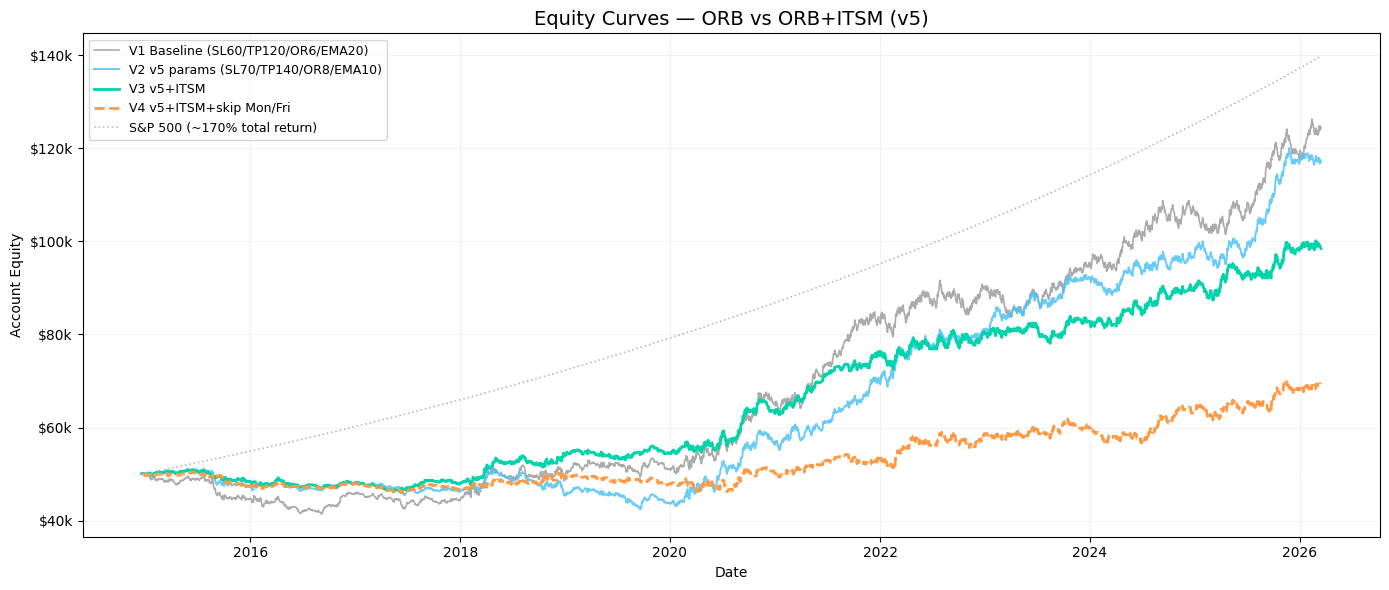

In [6]:
# Build S&P 500 benchmark equity curve (scaled to INITIAL_EQUITY)
start = min(eq1.index[0], eq2.index[0])
end   = max(eq1.index[-1], eq2.index[-1])
years = (end - start).days / 365.25
cagr_sp500  = (1 + SP500_RETURN / 100) ** (1 / years) - 1 if years > 0 else 0
biz_days    = pd.bdate_range(start, end)
daily_ret   = (1 + cagr_sp500) ** (1 / 252) - 1
sp500_eq    = pd.Series(
    INITIAL_EQUITY * (1 + daily_ret) ** np.arange(len(biz_days)),
    index=biz_days,
    name='S&P 500'
)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(eq1.index, eq1.values,  color='#888888', linewidth=1.2, label='V1 Baseline (SL60/TP120/OR6/EMA20)', alpha=0.7)
ax.plot(eq2.index, eq2.values,  color='#4fc3f7', linewidth=1.4, label='V2 v5 params (SL70/TP140/OR8/EMA10)', alpha=0.85)
ax.plot(eq3.index, eq3.values,  color='#00d4aa', linewidth=2.0, label='V3 v5+ITSM')
ax.plot(eq4.index, eq4.values,  color='#ff9944', linewidth=2.0, label='V4 v5+ITSM+skip Mon/Fri', linestyle='--')
ax.plot(sp500_eq.index, sp500_eq.values, color='#aaaaaa', linewidth=1.2,
        linestyle=':', label=f'S&P 500 (~{SP500_RETURN:.0f}% total return)', alpha=0.8)

ax.axhline(INITIAL_EQUITY, color='white', linewidth=0.6, linestyle='--', alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.set_title('Equity Curves — ORB vs ORB+ITSM (v5)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Account Equity')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.15)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'v5_equity_curves.png'), dpi=150)
plt.show()

## Trade Count & Win Rate Comparison

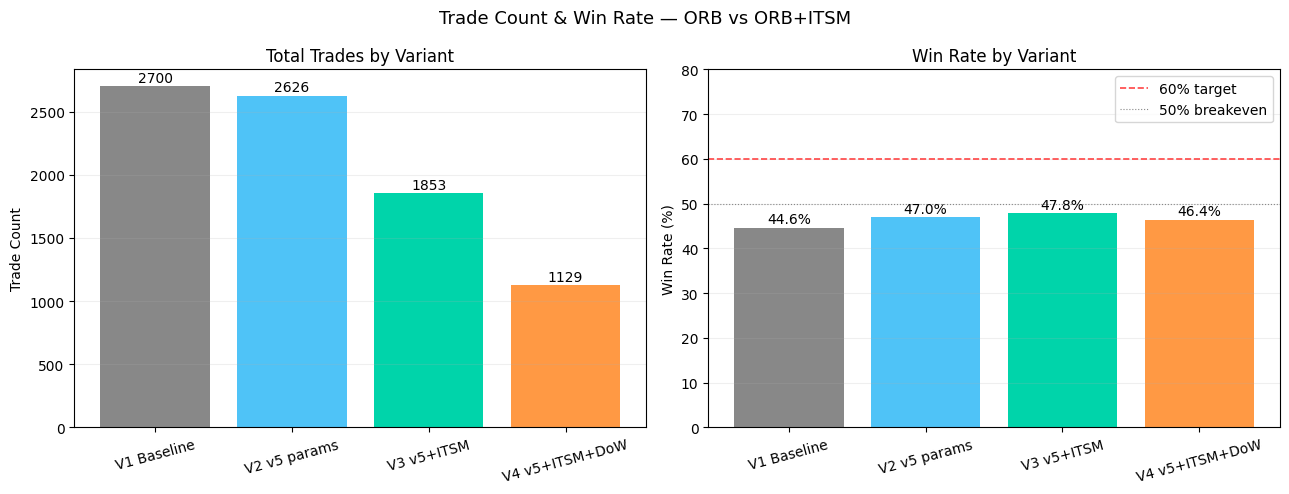

In [7]:
labels   = ['V1 Baseline', 'V2 v5 params', 'V3 v5+ITSM', 'V4 v5+ITSM+DoW']
counts   = [len(t1), len(t2), len(t3), len(t4)]
wrates   = [
    (t1['pnl'] > 0).mean() * 100 if not t1.empty else 0,
    (t2['pnl'] > 0).mean() * 100 if not t2.empty else 0,
    (t3['pnl'] > 0).mean() * 100 if not t3.empty else 0,
    (t4['pnl'] > 0).mean() * 100 if not t4.empty else 0,
]
colors   = ['#888888', '#4fc3f7', '#00d4aa', '#ff9944']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
bars = ax.bar(labels, counts, color=colors)
for b, v in zip(bars, counts):
    ax.text(b.get_x() + b.get_width() / 2, v + 10, str(v),
            ha='center', va='bottom', fontsize=10)
ax.set_title('Total Trades by Variant')
ax.set_ylabel('Trade Count')
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.2)

ax = axes[1]
bars = ax.bar(labels, wrates, color=colors)
ax.axhline(60, color='#ff4444', linewidth=1.2, linestyle='--', label='60% target')
ax.axhline(50, color='#888888', linewidth=0.8, linestyle=':', label='50% breakeven')
for b, v in zip(bars, wrates):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.3, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=10)
ax.set_title('Win Rate by Variant')
ax.set_ylabel('Win Rate (%)')
ax.set_ylim(0, 80)
ax.tick_params(axis='x', rotation=15)
ax.legend()
ax.grid(axis='y', alpha=0.2)

fig.suptitle('Trade Count & Win Rate — ORB vs ORB+ITSM', fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'v5_count_winrate.png'), dpi=150)
plt.show()

## Direction Split (V3: v5+ITSM)

In [8]:
def dir_stats(trades, label):
    for d, col in [('LONG', '#00d4aa'), ('SHORT', '#ff9944')]:
        sub = trades[trades['direction'] == d]
        if sub.empty:
            continue
        wr  = (sub['pnl'] > 0).mean() * 100
        net = sub['pnl'].sum()
        print(f'  {label} | {d:5s}: {len(sub):>4} trades, {wr:.1f}% WR, ${net:,.0f} net')

print('--- V1 Baseline ---')
dir_stats(t1, 'V1')
print('--- V2 v5 params ---')
dir_stats(t2, 'V2')
print('--- V3 v5+ITSM ---')
dir_stats(t3, 'V3')
print('--- V4 v5+ITSM+DoW ---')
dir_stats(t4, 'V4')

--- V1 Baseline ---
  V1 | LONG : 1473 trades, 46.8% WR, $42,468 net
  V1 | SHORT: 1227 trades, 42.0% WR, $31,848 net
--- V2 v5 params ---
  V2 | LONG : 1435 trades, 49.3% WR, $34,635 net
  V2 | SHORT: 1191 trades, 44.3% WR, $32,470 net
--- V3 v5+ITSM ---
  V3 | LONG : 1026 trades, 50.8% WR, $24,303 net
  V3 | SHORT:  827 trades, 44.1% WR, $24,141 net
--- V4 v5+ITSM+DoW ---
  V4 | LONG :  589 trades, 50.1% WR, $14,166 net
  V4 | SHORT:  540 trades, 42.4% WR, $5,175 net


## Exit Reason Breakdown

In [9]:
def exit_breakdown(trades, label):
    counts = trades['exit_reason'].value_counts()
    total  = len(trades)
    parts  = [f'{r}: {n} ({n/total*100:.0f}%)' for r, n in counts.items()]
    print(f'{label}: {" | ".join(parts)}')

exit_breakdown(t1, 'V1 Baseline ')
exit_breakdown(t2, 'V2 v5 params')
exit_breakdown(t3, 'V3 v5+ITSM  ')
exit_breakdown(t4, 'V4 v5+ITSM+DoW')

V1 Baseline : EOD: 1478 (55%) | SL: 849 (31%) | TP: 373 (14%)
V2 v5 params: EOD: 1632 (62%) | SL: 705 (27%) | TP: 289 (11%)
V3 v5+ITSM  : EOD: 1162 (63%) | SL: 497 (27%) | TP: 194 (10%)
V4 v5+ITSM+DoW: EOD: 686 (61%) | SL: 319 (28%) | TP: 124 (11%)


## Sharpe / Max Drawdown / Total Return vs S&P 500

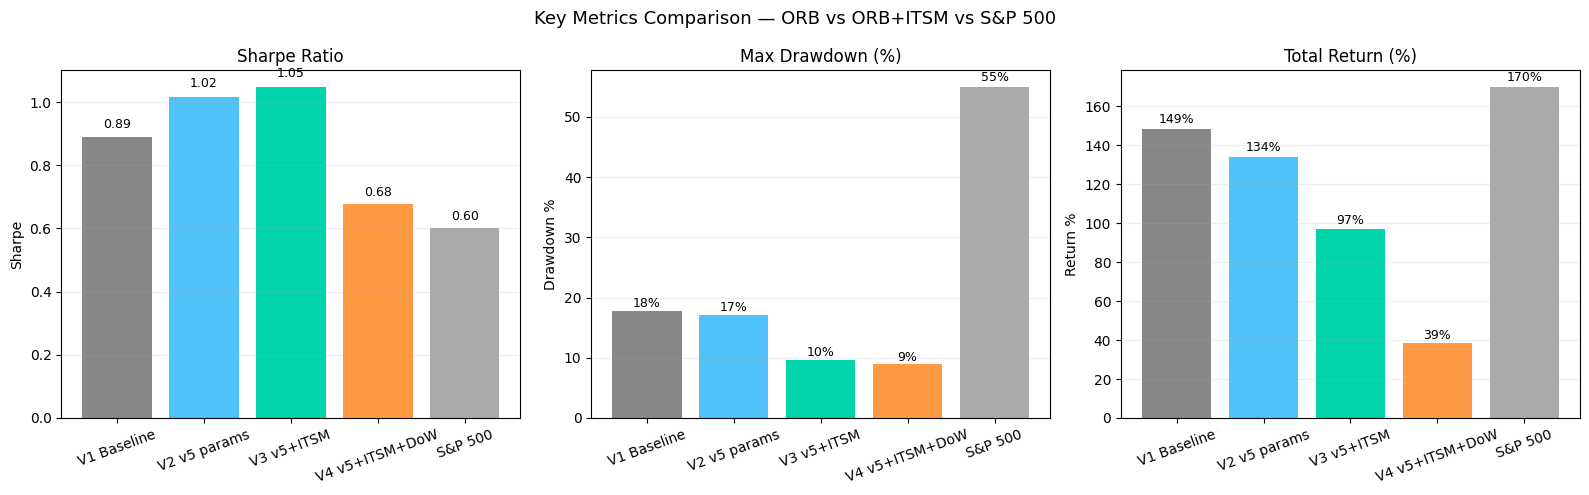

In [10]:
import re

def get_float(s):
    m = re.search(r'[-\d.]+', str(s))
    return float(m.group()) if m else float('nan')

variant_labels  = ['V1 Baseline', 'V2 v5 params', 'V3 v5+ITSM', 'V4 v5+ITSM+DoW', 'S&P 500']
variant_metrics = [m1, m2, m3, m4, sp500_row]
var_colors      = ['#888888', '#4fc3f7', '#00d4aa', '#ff9944', '#aaaaaa']

sharpes  = [get_float(m.get('Sharpe', 0))       for m in variant_metrics]
maxdds   = [get_float(m.get('Max Drawdown', 0)) for m in variant_metrics]
returns  = [get_float(m.get('Total Return', 0)) for m in variant_metrics]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, vals, title, ylabel, ref, ref_label in [
    (axes[0], sharpes, 'Sharpe Ratio',    'Sharpe',  None,  None),
    (axes[1], maxdds,  'Max Drawdown (%)', 'Drawdown %', None, None),
    (axes[2], returns, 'Total Return (%)', 'Return %',   None, None),
]:
    bars = ax.bar(variant_labels, vals, color=var_colors)
    for b, v in zip(bars, vals):
        if not (v != v):  # skip NaN
            ax.text(b.get_x() + b.get_width() / 2, v + abs(v) * 0.01 + 0.01,
                    f'{v:.2f}' if title == 'Sharpe Ratio' else f'{v:.0f}%',
                    ha='center', va='bottom', fontsize=9)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', alpha=0.2)

fig.suptitle('Key Metrics Comparison — ORB vs ORB+ITSM vs S&P 500', fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'v5_metrics_comparison.png'), dpi=150)
plt.show()

## Summary & Conclusion

In [11]:
print('=' * 65)
print(' Backtest v5 -- ORB + ITSM Summary')
print('=' * 65)

rows = [
    ('V1 Baseline',       t1, m1),
    ('V2 v5 params',      t2, m2),
    ('V3 v5+ITSM',        t3, m3),
    ('V4 v5+ITSM+DoW',    t4, m4),
]

for label, trades, m in rows:
    wr      = get_float(m.get('Win Rate', 0))
    sharpe  = get_float(m.get('Sharpe', 0))
    ret     = get_float(m.get('Total Return', 0))
    mdd     = get_float(m.get('Max Drawdown', 0))
    pnl     = m.get('Net P&L', '$0')
    wr_flag = 'PASS' if wr >= 60 else ('OK' if wr >= 50 else 'FAIL')
    sr_flag = 'PASS' if sharpe > 1.0 else ('OK' if sharpe > 0.6 else 'FAIL')
    print(f'\n {label}')
    print(f'   Trades       : {len(trades)}')
    print(f'   Win Rate     : {wr:.1f}%  [{wr_flag}] (target >= 60%)')
    print(f'   Sharpe       : {sharpe:.3f}  [{sr_flag}] (S&P 500 ~0.60)')
    print(f'   Max Drawdown : {mdd:.1f}%')
    print(f'   Total Return : {ret:.1f}%')
    print(f'   Net P&L      : {pnl}')

print()
print('-' * 65)
wr3 = get_float(m3.get('Win Rate', 0))
sr3 = get_float(m3.get('Sharpe', 0))
if wr3 >= 60 and sr3 > 1.0:
    verdict = 'PROCEED -- v5+ITSM beats both WR and Sharpe targets'
elif wr3 >= 60 or sr3 > 1.0:
    verdict = 'PARTIAL -- meets one target; review trade-offs'
else:
    verdict = 'INVESTIGATE -- neither target met; check ITSM direction logic'
print(f' Verdict (V3 v5+ITSM): {verdict}')
print('=' * 65)

 Backtest v5 -- ORB + ITSM Summary

 V1 Baseline
   Trades       : 2700
   Win Rate     : 44.6%  [FAIL] (target >= 60%)
   Sharpe       : 0.890  [OK] (S&P 500 ~0.60)
   Max Drawdown : 17.7%
   Total Return : 148.6%
   Net P&L      : $74,316

 V2 v5 params
   Trades       : 2626
   Win Rate     : 47.0%  [FAIL] (target >= 60%)
   Sharpe       : 1.017  [PASS] (S&P 500 ~0.60)
   Max Drawdown : 17.1%
   Total Return : 134.2%
   Net P&L      : $67,106

 V3 v5+ITSM
   Trades       : 1853
   Win Rate     : 47.8%  [FAIL] (target >= 60%)
   Sharpe       : 1.048  [PASS] (S&P 500 ~0.60)
   Max Drawdown : 9.7%
   Total Return : 96.9%
   Net P&L      : $48,444

 V4 v5+ITSM+DoW
   Trades       : 1129
   Win Rate     : 46.4%  [FAIL] (target >= 60%)
   Sharpe       : 0.677  [OK] (S&P 500 ~0.60)
   Max Drawdown : 8.9%
   Total Return : 38.7%
   Net P&L      : $19,341

-----------------------------------------------------------------
 Verdict (V3 v5+ITSM): PARTIAL -- meets one target; review trade-offs
